# Análise de Custos de Expedição (Shipping %)

Esta análise foca-se na proporção dos custos de expedição face ao preço de venda (Shipping %), detalhado por Categoria Principal de Produto, Região e Ano.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

# Carregar dados
df = pd.read_csv('../data/sales_data_clean.csv', parse_dates=['Order_Date'])

# Calcular % de Shipping (Shipping Ratio em %)
df['Shipping_pct'] = (df['Shipping_Cost'] / df['Sales_Price']) * 100

print(f"Total de registos: {len(df):,}")
print(f"Média global de Shipping %: {df['Shipping_pct'].mean():.2f}%")


Total de registos: 147,511
Média global de Shipping %: 1.80%


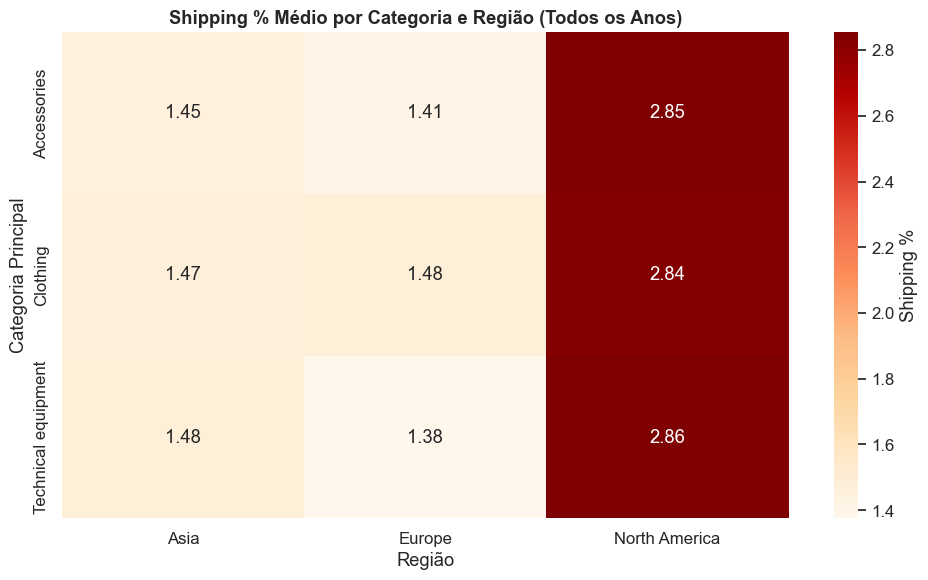

In [2]:
# Agrupar por Categoria, Região e Ano
shipping_agg = df.groupby(['Main_Category', 'Region', 'Year'])['Shipping_pct'].mean().reset_index()

# Visualização 1: Heatmap geral por Categoria e Região (Média de todos os anos)
plt.figure(figsize=(10, 6))
pivot_cat_reg = df.pivot_table(index='Main_Category', columns='Region', values='Shipping_pct', aggfunc='mean')
sns.heatmap(pivot_cat_reg, annot=True, fmt='.2f', cmap='OrRd', cbar_kws={'label': 'Shipping %'})
plt.title('Shipping % Médio por Categoria e Região (Todos os Anos)', fontweight='bold')
plt.ylabel('Categoria Principal')
plt.xlabel('Região')
plt.tight_layout()
plt.show()


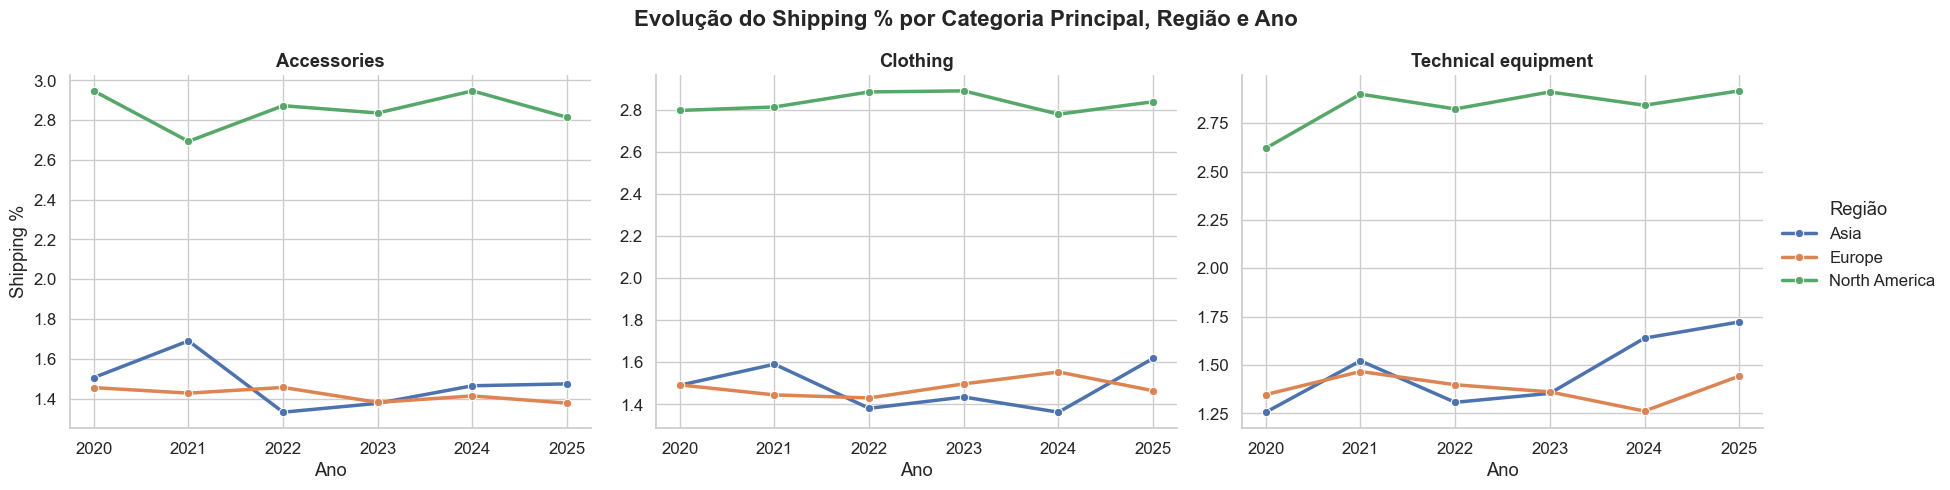

In [3]:
# Visualização 2: Evolução temporal por Categoria e Região
import matplotlib.ticker as mticker

g = sns.FacetGrid(shipping_agg, col='Main_Category', col_wrap=3, height=5, aspect=1.2, sharey=False)
g.map_dataframe(sns.lineplot, x='Year', y='Shipping_pct', hue='Region', marker='o', linewidth=2.5)
g.add_legend(title='Região')
g.set_axis_labels("Ano", "Shipping %")
g.set_titles(col_template="{col_name}", fontweight='bold')

for ax in g.axes.flatten():
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Evolução do Shipping % por Categoria Principal, Região e Ano', fontweight='bold', fontsize=16)
plt.show()


In [4]:
# Tabela resumo: Shipping % por Categoria, Região e Ano
pivot_all = df.pivot_table(index=['Main_Category', 'Region'], columns='Year', values='Shipping_pct', aggfunc='mean')

print("Tabela Detalhada: Shipping % por Categoria, Região e Ano")
display(pivot_all.round(2))


Tabela Detalhada: Shipping % por Categoria, Região e Ano


Year                               2020  2021  2022  2023  2024  2025
Main_Category       Region                                           
Accessories         Asia           1.51  1.69  1.33  1.38  1.46  1.47
                    Europe         1.46  1.43  1.46  1.38  1.41  1.38
                    North America  2.95  2.69  2.87  2.84  2.95  2.81
Clothing            Asia           1.49  1.59  1.38  1.43  1.36  1.62
                    Europe         1.49  1.44  1.43  1.50  1.55  1.46
                    North America  2.80  2.81  2.89  2.89  2.78  2.84
Technical equipment Asia           1.26  1.52  1.31  1.35  1.64  1.72
                    Europe         1.35  1.47  1.40  1.36  1.26  1.44
                    North America  2.62  2.90  2.82  2.91  2.84  2.92